# Credit Card Fraud Detection

In [14]:
# Setup - imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optional models
try: 
    import xgboost as xgb
except Exception as e:
    print("XGBoost is not installed.", e)

try:
    import lightgbm as lgb
except Exception as e:
    lgb = None
    print("LightGBM is not installed.", e)

import joblib

print("Setup complete")

XGBoost is not installed. 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/omar/Documents/credit_card-fraud-detection/venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/omar/Documents/credit_card-fraud-detection/venv/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes

In [15]:
import sys
print(sys.executable)

/Users/omar/Documents/credit_card-fraud-detection/venv/bin/python


In [16]:
# 1. Load data
DATA_PATH = "creditcard.csv"
assert os.path.exists(DATA_PATH), f"Data file not found at {DATA_PATH}"
df= pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dataset shape: (284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing valuees (top 20): 
 Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
dtype: int64

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.001727485630620034


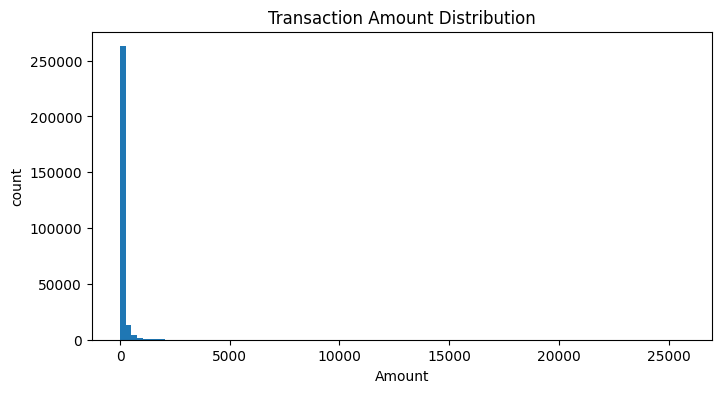

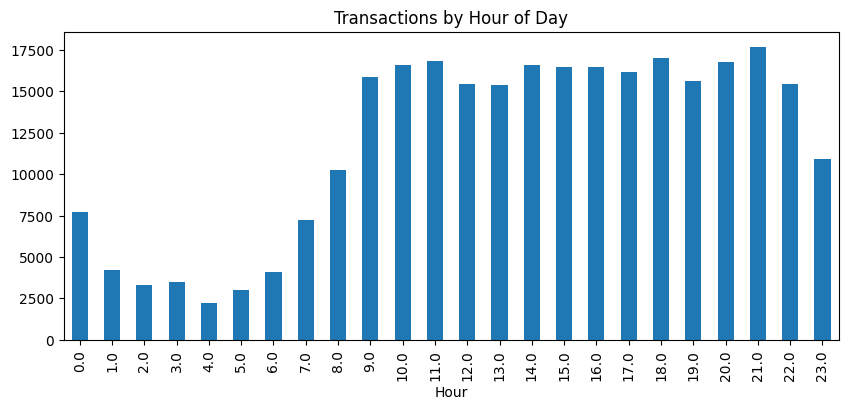

In [17]:
# 2. Quick EDA
print("Dataset shape:", df.shape)
print(df.dtypes)
print('\nMissing valuees (top 20): \n', df.isnull().sum().sort_values(ascending=False).head(20))
target_col = 'Class'
print("\nTarget distribution:")
print(df[target_col].value_counts())
print('Fraud ratio:', df[target_col].mean())

# Amount distribution
plt.figure(figsize=(8,4))
plt.hist(df['Amount'], bins=100)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('count')
plt.show()

# Time-based overview (the dataset's Time column in seconds since first transaction)
if 'Time' in df.columns:
    df['Hour'] = (df['Time'] // 3600) % 24
    plt.figure(figsize=(10,4))
    df.groupby('Hour').size().plot(kind='bar')
    plt.title('Transactions by Hour of Day')
    plt.show()

# Data Analysis

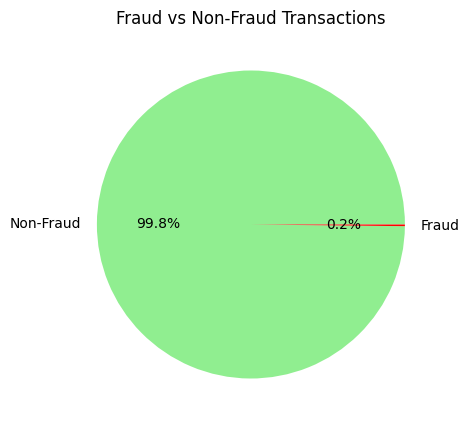

In [18]:
# Pie chart
plt.figure(figsize=(5,5))
plt.pie(df['Class'].value_counts().values, labels=['Non-Fraud', 'Fraud'], autopct='%1.1f%%', colors=['lightgreen', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

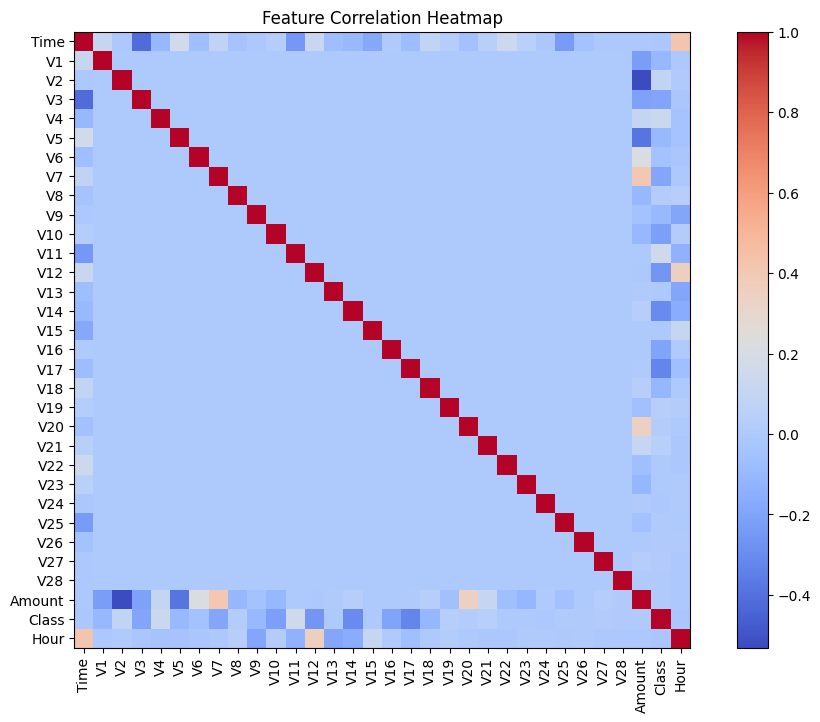

In [19]:
# Coorrelation heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Heatmap')
plt.show()

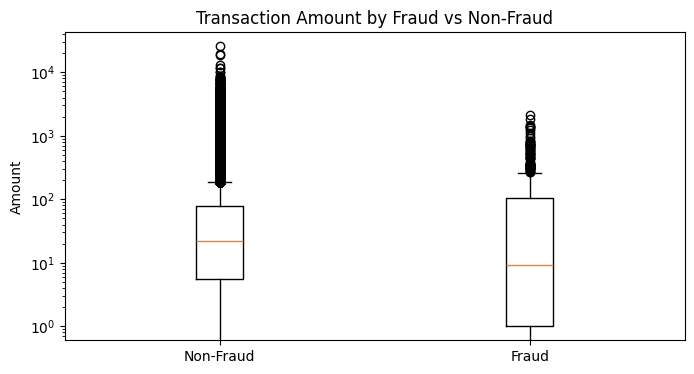

In [20]:
# Fraud vs Non-Fraud Amount
plt.figure(figsize=(8,4))
amount_nonfraud = df[df['Class'] == 0]['Amount']
amount_fraud = df[df['Class'] == 1]['Amount']
plt.boxplot([amount_nonfraud, amount_fraud], labels=['Non-Fraud', 'Fraud'])
plt.ylabel('Amount')
plt.yscale('log')
plt.title('Transaction Amount by Fraud vs Non-Fraud')
plt.show()